# Predicting Customer Churn & Lifetime Value using Machine Learning

**Business Overview**

A telecommunications company provides internet, phone, and streaming services to thousands of customers. Customer retention has become a critical business challenge as acquiring new customers is significantly more expensive than retaining existing ones.
The company has observed an increasing number of customers terminating their subscriptions (customer churn), resulting in revenue loss and increased acquisition costs.
To address this issue, the management team requires a data-driven analysis to identify the key factors contributing to customer churn and provide actionable recommendations to improve customer retention.

**Business Problem:**

The company currently lacks clear visibility into:
- Which customers are most likely to churn
- What customer characteristics contribute to churn
- Which services are associated with higher churn
- Which customer segments generate the highest revenue
- How contract type influences customer retention

**Business Objectives**

This project aims to:
- Analyze customer churn behavior
- Identify factors affecting churn
- Measure customer value
- Build an executive dashboard
- Provide business recommendations to reduce churn

**Key Business Questions**
1. What is the overall churn rate?
2. Which customer segments experience has the highest churn?
3. How does contract type influence customer churn?
4. How does customer tenure affect churn?
5. Which internet services and additional services are associated with higher churn?
6. Does payment method influence customer churn?
7. Which customer segments contribute the highest revenue and customer lifetime value (CLV)?
8. What business actions can reduce churn while maximizing customer value?

# Connect to GDrive

In [ ]:
from google.colab import drive
drive.mount ("/content/gdrive")

Mounted at /content/gdrive


# Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [ ]:
#Path definition
path ='/content/gdrive/MyDrive/Portfolio/Customer Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

#Read the CSV file
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning/Data Quality Check

## Missing Value

In [ ]:
missing = pd.DataFrame ({
    'total_missing': df.isnull().sum()
    })
missing

,total_missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Check Blank String

In [ ]:
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

## Unique Value

In [ ]:
unique=pd.DataFrame({
    'unique': df.nunique()
    })
unique

,unique
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


## Check Categorical Distribution

In [ ]:
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts())

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes               

## Convert Data Type

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Feature Engineering

In [ ]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = df[service_cols].apply(
    lambda x: sum(
        value in ['Yes', 'DSL', 'Fiber optic']
        for value in x
    ),
    axis=1
)
service_cols

['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

## Monthly Revenue

In [ ]:
df["MonthlyRevenue"] = df["MonthlyCharges"]
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,MonthlyRevenue
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,4,56.95
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,53.85
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,42.30
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,70.70


## Customer Lifetime Value

In [ ]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,MonthlyRevenue,CLV
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,4,56.95,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,53.85,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,42.30,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,70.70,141.40


## Tenure Group

In [ ]:
bins = [0,12,24,48,72]

labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-72 Months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,MonthlyRevenue,CLV,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,29.85,29.85,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,4,56.95,1936.30,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,53.85,107.70,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,42.30,1903.50,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,70.70,141.40,0-12 Months


# Feature Validation

In [ ]:
df[['customerID',
    'tenure',
    'TenureGroup',
    'TotalServices',
    'MonthlyCharges',
    'CLV']].head()

,customerID,tenure,TenureGroup,TotalServices,MonthlyCharges,CLV
0,7590-VHVEG,1,0-12 Months,2,29.85,29.85
1,5575-GNVDE,34,25-48 Months,4,56.95,1936.30
2,3668-QPYBK,2,0-12 Months,4,53.85,107.70
3,7795-CFOCW,45,25-48 Months,4,42.30,1903.50
4,9237-HQITU,2,0-12 Months,2,70.70,141.40


# Save Data Clean

In [ ]:
save_path="/content/gdrive/MyDrive/Portfolio/Customer Churn/telco_clean.csv"

df.to_csv(save_path,index=False)

# Exploratory Data Analysis (EDA)

## Executive KPI Overview

### Total Customer

In [ ]:
total_customer = df['customerID'].nunique()

print(f"Total Customers : {total_customer}")

Total Customers : 7043


### Churn Rate Distribution

In [ ]:
churn_summary = (
    df['Churn']
    .value_counts()
    .reset_index()
)

churn_summary.columns = ['Churn','Customers']

churn_summary['Percentage'] = (
    churn_summary['Customers']
    / churn_summary['Customers'].sum()
    *100
).round(2)

churn_summary

,Churn,Customers,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


### Total Monthly Revenue

In [ ]:
df['MonthlyCharges'].sum()
print(f"Total Monthly Revenue : {df['MonthlyCharges'].sum()}")

Total Monthly Revenue : 456116.6


### Average Monthly Revenue

In [ ]:
df['MonthlyCharges'].mean()
print(f"Average Monthly Charge : {df['MonthlyCharges'].mean()}")

Average Monthly Charge : 64.76169246059918


### Average Customer Lifetime Value

In [ ]:
df['tenure'].mean()
print(f"Average Customer Lifetime : {df['tenure'].mean()}")

Average Customer Lifetime : 32.37114865824223


### Average Cust Lifetime Value

In [ ]:
df['CLV'].mean()
print(f"Average Customer Lifetime Value : {df['CLV'].mean()}")

Average Customer Lifetime Value : 2279.5813502768706


## Business Question

### Overall Customer Churn Rate

In [ ]:
churn_rate = (
    df['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_rate

,proportion
Churn,
No,73.46
Yes,26.54


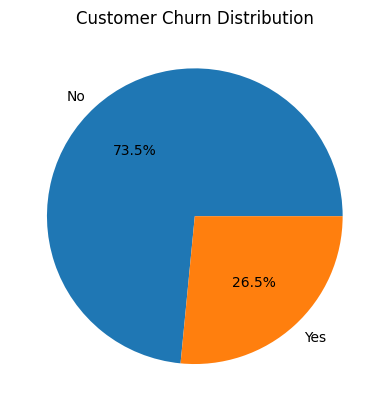

In [ ]:
# Visualization

(
    df['Churn']
    .value_counts()
    .plot(kind='pie',
          autopct='%1.1f%%',
          ylabel='')
)

plt.title("Customer Churn Distribution")
plt.show()

Insight :
Around 26.6% of customers have churned, indicating that customer retention should become one of the company's strategic priorities.

###  Contract type with the highest churn

In [ ]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


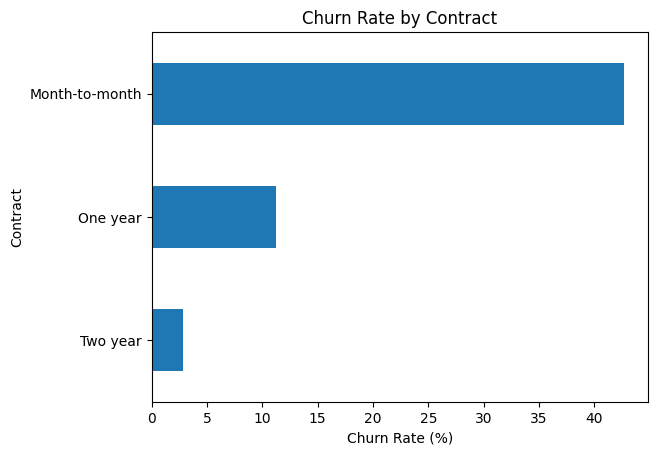

In [ ]:
# Visualisasi

contract_churn['Yes'].sort_values().plot(kind='barh')
plt.title("Churn Rate by Contract")
plt.xlabel("Churn Rate (%)")
plt.show()

Insight:
Customers on month-to-month contracts generally exhibit the highest churn rate compared with customers on longer-term contracts

### Internet Service with the Highest Churn

In [ ]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


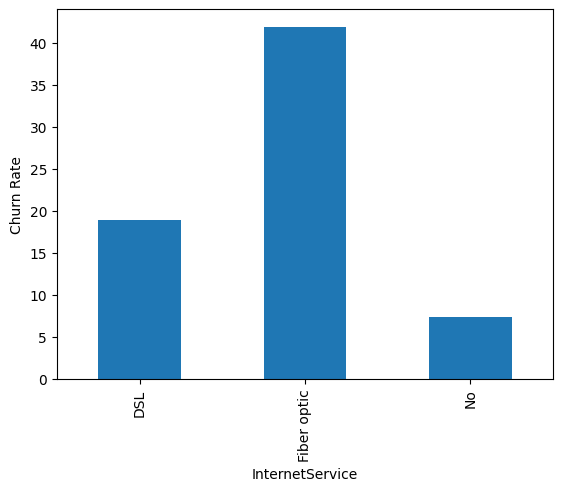

In [ ]:
# Visualization

internet_churn['Yes'].plot(kind='bar')
plt.ylabel("Churn Rate")
plt.show()

Insight:
Compare churn rates across Fiber optic, DSL, and No Internet Service to identify the segment with the greatest retention challenge

### Tenure Affect Churn

In [ ]:
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.56,47.44
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


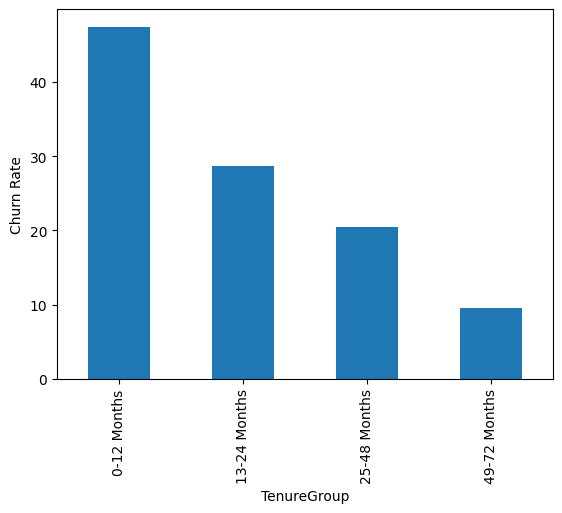

In [ ]:
# Visualization

tenure_churn['Yes'].plot(kind='bar')
plt.ylabel("Churn Rate")
plt.show()

Insight:
Customers with shorter tenure generally tend to churn more frequently than long-tenured customers.

### Payment method with the highest churn

In [ ]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


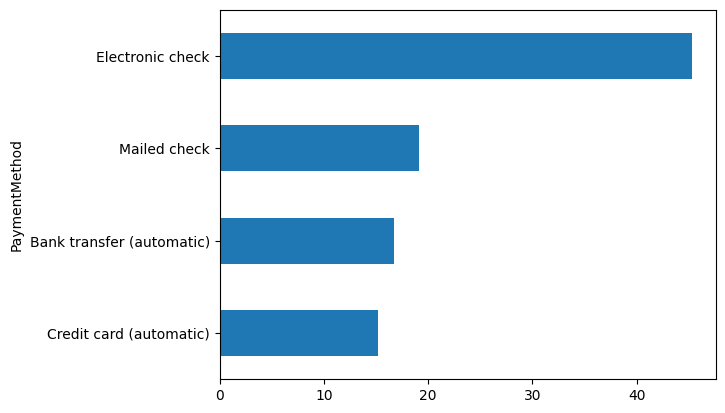

In [ ]:
# Visualization

payment_churn['Yes'].sort_values().plot(kind='barh')
plt.show()

Insight :
Payment methods with relatively high churn may indicate customer friction or reflect characteristics of specific customer segments.

### Tech Support Reduce Churn?

In [ ]:
tech_support = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

tech_support

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


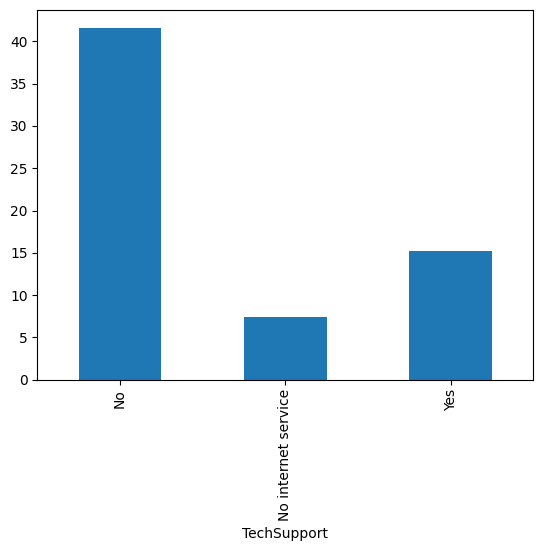

In [ ]:
# Visualization

tech_support['Yes'].plot(kind='bar')
plt.show()

Insight:

Compare churn rates between customers with and without Tech Support to assess whether support services are associated with higher retention.

### Online Security reduce churn?

In [ ]:
security = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

security

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


### Customer Segment that generate high revenue

In [ ]:
revenue_contract = (
    df
    .groupby('Contract', as_index=False)
    ['MonthlyCharges']
    .sum()
    .sort_values('MonthlyCharges', ascending=False)
)

revenue_contract

,Contract,MonthlyCharges
0,Month-to-month,257294.15
2,Two year,103005.85
1,One year,95816.60


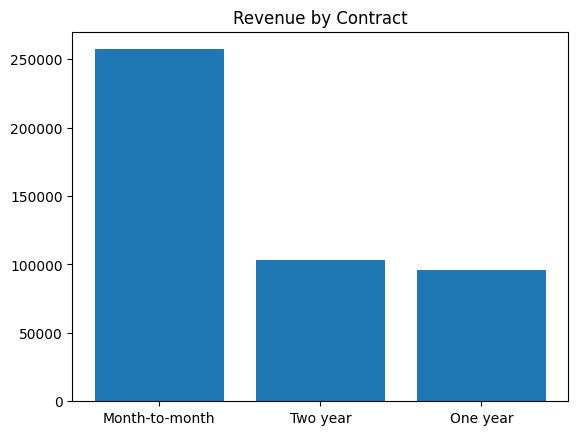

In [ ]:
# Visualization

plt.bar(
    revenue_contract['Contract'],
    revenue_contract['MonthlyCharges']
)

plt.title("Revenue by Contract")

plt.show()

Insight

Revenue contribution varies across contract types and should be evaluated alongside churn to prioritize high-value customer segments.

### Tenure group contributes the highest revenue

In [ ]:
revenue_tenure = (
    df
    .groupby('TenureGroup', as_index=False)
    ['MonthlyCharges']
    .sum()
)

revenue_tenure

/tmp/ipykernel_994/2143810597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('TenureGroup', as_index=False)


,TenureGroup,MonthlyCharges
0,0-12 Months,122629.75
1,13-24 Months,62829.85
2,25-48 Months,105093.30
3,49-72 Months,165563.70


### Total services does each customer subscribe

In [ ]:
service_distribution = (
    df['TotalServices']
    .value_counts()
    .sort_index()
)

service_distribution

,count
TotalServices,
1,1264
2,859
3,846
4,965
5,922
6,908
7,676
8,395
9,208


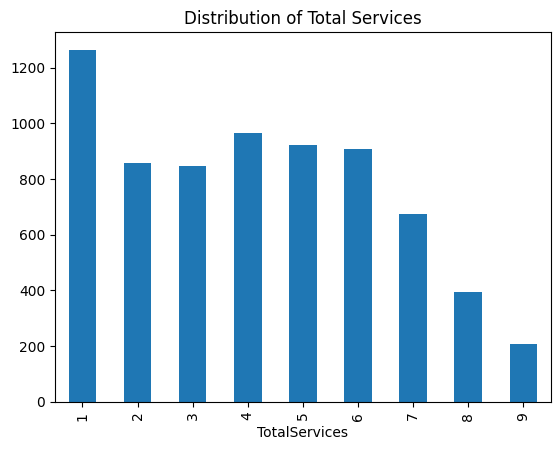

In [ ]:
# Visualization

service_distribution.plot(kind='bar')

plt.title("Distribution of Total Services")

plt.show()

### number of subscribed services influence churn

In [ ]:
service_churn = pd.crosstab(
    df['TotalServices'],
    df['Churn'],
    normalize='index'
).mul(100).round(2)

service_churn

Churn,No,Yes
TotalServices,,
1,89.08,10.92
2,69.03,30.97
3,55.08,44.92
4,63.52,36.48
5,68.66,31.34
6,74.45,25.55
7,77.51,22.49
8,87.59,12.41
9,94.71,5.29


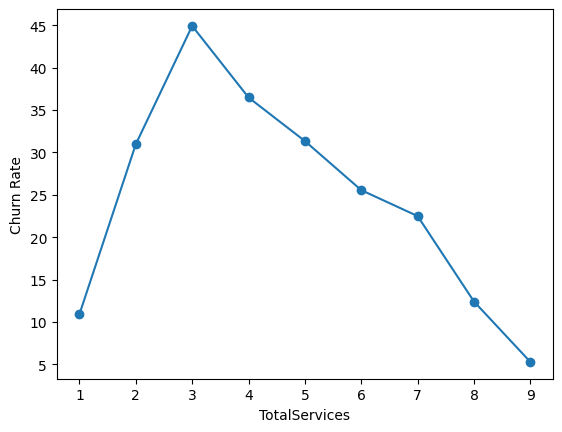

In [ ]:
# Visualization

service_churn['Yes'].plot(marker='o')

plt.ylabel("Churn Rate")

plt.show()

Insight

This analysis helps determine whether customers using more services are less likely to churn, indicating potential benefits of cross-selling.

### Customer profile has the highest churn

In [ ]:
profile = pd.pivot_table(
    df,
    values='customerID',
    index=['Contract','InternetService'],
    columns='Churn',
    aggfunc='count',
    fill_value=0
)

profile['Churn Rate (%)'] = (
    profile['Yes']
    /(profile['Yes']+profile['No'])
    *100
).round(2)

profile.sort_values(
    'Churn Rate (%)',
    ascending=False
)

Churn                            No   Yes  Churn Rate (%)
Contract       InternetService                           
Month-to-month Fiber optic      966  1162           54.61
               DSL              829   394           32.22
One year       Fiber optic      435   104           19.29
Month-to-month No               425    99           18.89
One year       DSL              517    53            9.30
Two year       Fiber optic      398    31            7.23
One year       No               355     9            2.47
Two year       DSL              616    12            1.91
               No               633     5            0.78

# Business Impact Analysis

## Revenue at Risk

In [ ]:
churn_df = df[df['Churn']=='Yes']

revenue_at_risk = pd.DataFrame({
    'Metric':[
        'Total Churn Customers',
        'Monthly Revenue at Risk',
        'Average Monthly Revenue'
    ],
    'Value':[
        churn_df['customerID'].count(),
        churn_df['MonthlyCharges'].sum(),
        churn_df['MonthlyCharges'].mean()
    ]
})

revenue_at_risk

,Metric,Value
0,Total Churn Customers,1869.000000
1,Monthly Revenue at Risk,139130.850000
2,Average Monthly Revenue,74.441332


In [ ]:
# Annual Projection

monthly_loss = df.loc[df['Churn']=="Yes","MonthlyCharges"].sum()

annual_loss = monthly_loss * 12

print(annual_loss)

1669570.2000000002


Assuming churned customers are not replaced immediately, the company could potentially lose approximately X in annual recurring revenue.

## Revenue at Risk by Contract

In [ ]:
risk_contract = (
    df[df['Churn']=="Yes"]
    .groupby('Contract',as_index=False)
    .agg(
        Customers=('customerID','count'),
        Revenue_At_Risk=('MonthlyCharges','sum')
    )
    .sort_values(
        'Revenue_At_Risk',
        ascending=False
    )
)

risk_contract

,Contract,Customers,Revenue_At_Risk
0,Month-to-month,1655,120847.10
1,One year,166,14118.45
2,Two year,48,4165.30


## Revenue at Risk by Internet Service

In [ ]:
risk_internet = (
    df[df['Churn']=="Yes"]
    .groupby('InternetService',as_index=False)
    .agg(
        Customers=('customerID','count'),
        Revenue_At_Risk=('MonthlyCharges','sum')
    )
    .sort_values(
        'Revenue_At_Risk',
        ascending=False
    )
)
risk_internet

,InternetService,Customers,Revenue_At_Risk
1,Fiber optic,1297,114300.05
0,DSL,459,22529.20
2,No,113,2301.60


## High Value Customer at Risk

In [ ]:
clv_threshold = df['CLV'].median()

high_value_risk = df[
    (df['CLV']>=clv_threshold)
    &
    (df['Churn']=="Yes")
]

high_value_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,MonthlyRevenue,CLV,TenureGroup
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,7,104.80,2934.40,25-48 Months
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,7,103.70,5081.30,49-72 Months
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,6,99.35,4669.45,25-48 Months
38,5380-WJKOV,Male,0,No,No,34,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,106.35,3549.25,Yes,7,106.35,3615.90,25-48 Months
51,9420-LOJKX,Female,0,No,No,15,Yes,No,Fiber optic,Yes,...,Month-to-month,Yes,Credit card (automatic),99.10,1426.40,Yes,6,99.10,1486.50,13-24 Months


In [ ]:
high_value_summary = pd.DataFrame({
    'Metric':[
        'High Value Customers',
        'Monthly Revenue at Risk',
        'Average CLV'
    ],
    'Value':[
        high_value_risk['customerID'].count(),
        high_value_risk['MonthlyCharges'].sum(),
        high_value_risk['CLV'].mean()
    ]
})

high_value_summary

,Metric,Value
0,High Value Customers,661.000000
1,Monthly Revenue at Risk,59631.350000
2,Average CLV,3615.618306


## Customer Risk Segmentation

In [ ]:
clv_median = df['CLV'].median()

def risk_segment(row):

    if row['Contract']=="Month-to-month" and row['CLV']>=clv_median:
        return "High Risk - High Value"

    elif row['Contract']=="Month-to-month":
        return "High Risk"

    elif row['CLV']>=clv_median:
        return "High Value"

    else:
        return "Low Risk"

df['RiskSegment']=df.apply(
    risk_segment,
    axis=1
)

In [ ]:
risk_summary = (
    df
    .groupby('RiskSegment')
    .agg(
        Customers=('customerID','count'),
        Revenue=('MonthlyCharges','sum'),
        AvgCLV=('CLV','mean')
    )
)

risk_summary

,Customers,Revenue,AvgCLV
RiskSegment,,,
High Risk,2547,144190.60,413.225795
High Risk - High Value,1328,113103.55,3205.353652
High Value,2194,172485.00,4567.282931
Low Risk,974,26337.45,744.637526


# Executive Summary

The overall churn rate is 26.58%, indicating that approximately one in four customers discontinued the service.
Customers on month-to-month contracts experience substantially higher churn than those on annual or two-year contracts.
Churn patterns vary by Internet Service and Payment Method, suggesting that service experience and billing preferences may influence customer retention.
Customers with shorter tenure are more likely to churn, highlighting the importance of effective onboarding and early engagement.
Customers subscribed to Tech Support and Online Security generally demonstrate better retention, presenting opportunities for cross-selling value-added services.
Combining churn risk with revenue contribution enables the business to prioritize retention initiatives for high-value customer segments.

# Key Findings

1. Customer Churn Remains a Significant Business Issue
Approximately one-quarter of the customer base has discontinued the service, representing a substantial risk to recurring revenue and long-term business growth.
Business Impact
Loss of recurring subscription revenue
Higher customer acquisition costs
Reduced customer lifetime value
2. Contract Type Is the Strongest Indicator of Customer Retention
Customers subscribed to month-to-month contracts demonstrate considerably higher churn rates than those committed to one-year or two-year contracts.
Business Interpretation
Long-term contractual commitments contribute to greater customer loyalty and lower attrition.
3. Early Lifecycle Customers Are More Likely to Churn
Customers with shorter tenure consistently exhibit higher churn rates compared with long-tenured customers.
Business Interpretation
The first year of the customer lifecycle represents the highest-risk period and should become the primary focus of retention efforts.
4. Value-Added Services Are Associated with Better Customer Retention
Customers who subscribe to additional services such as Tech Support and Online Security generally experience lower churn compared with customers who do not.
Business Interpretation
Customers who perceive greater service value tend to remain with the company longer.
5. Revenue Contribution Is Uneven Across Customer Segments
Revenue is concentrated within specific customer groups. Evaluating churn together with customer value enables the business to identify high-value customers who should be prioritized for retention campaigns.
6. Customer Characteristics Influence Churn Behavior
Customer demographics alone provide limited explanatory power. Instead, churn appears to be more closely associated with customer experience, service utilization, and subscription behavior.

# Recommendation

1. Strengthen Early Customer Retention Programs

Objective

Reduce churn among newly acquired customers.

Recommended Actions

- Launch onboarding campaigns during the first 90 days.
- Conduct proactive follow-up calls or emails for new customers.
- Provide educational content highlighting available services and product benefits.
- Offer introductory incentives to encourage long-term engagement.

Expected Business Outcome

- Improved customer satisfaction
- Reduced early-stage churn
- Increased customer lifetime value

2. Encourage Migration to Long-Term Contracts

Objective

Increase customer retention by promoting longer subscription commitments.

Recommended Actions

- Provide discounts for annual contracts.
- Introduce loyalty rewards for contract renewals.
- Offer bundled packages exclusively for long-term subscribers.

Expected Business Outcome

- Higher customer retention
- More predictable recurring revenue
- Lower acquisition costs

3. Increase Adoption of Value-Added Services

Objective

Improve customer stickiness through additional service offerings.

Recommended Actions

- Bundle Tech Support with premium internet packages.
- Promote Online Security as an essential service.
- Create personalized cross-selling campaigns based on customer profiles.

Expected Business Outcome

- Higher average revenue per customer
- Lower churn probability
- Increased perceived service value

4. Develop a Churn Risk Monitoring Dashboard

Objective

Enable proactive intervention before customers decide to leave.

Recommended Actions

Monitor customers with characteristics such as:
- Month-to-month contracts
- Short tenure
- Limited subscribed services
- High monthly charges
- Recent service changes

Expected Business Outcome

- Earlier identification of high-risk customers
- More effective retention campaigns
- Better allocation of customer success resources

5. Prioritize High-Value Customer Retention

Objective

Protect customers contributing the highest business value.

Recommended Actions

Segment customers based on:
- Customer Lifetime Value (CLV)
- Monthly Revenue
- Contract Type
- Churn Risk
Provide exclusive retention programs for customers combining high value and high churn risk.

Expected Business Outcome

- Reduced revenue loss
- Improved profitability
- Increased customer lifetime value

# Business Conclusion

This analysis demonstrates that customer churn is influenced primarily by customer engagement and subscription behavior rather than demographic characteristics. Customers with shorter tenure, flexible contracts, and fewer subscribed services consistently exhibit higher churn risk.
By combining customer segmentation, churn analysis, and revenue metrics into a unified executive dashboard, management can proactively identify high-risk customer groups and implement targeted retention strategies. These insights support data-driven decision making and help maximize long-term customer value while reducing revenue leakage.

# Potential Business Impact

| Recommendation                     | Expected KPI Impact                                              |
| ---------------------------------- | ---------------------------------------------------------------- |
| Early Retention Program            | Lower churn rate among new customers                             |
| Long-Term Contract Campaign        | Higher contract renewal rate                                     |
| Cross-Selling Value-Added Services | Higher Average Revenue per User (ARPU)                           |
| Churn Monitoring Dashboard         | Faster identification of at-risk customers                       |
| High-Value Customer Retention      | Increased Customer Lifetime Value (CLV) and reduced revenue loss |
